In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('/home/husain/Desktop/datascience_conda/Project-DA/bikes/job_NXXoTBjvWF7RG-8nqYw406QqSzde.csv')
df.shape


(14, 3)

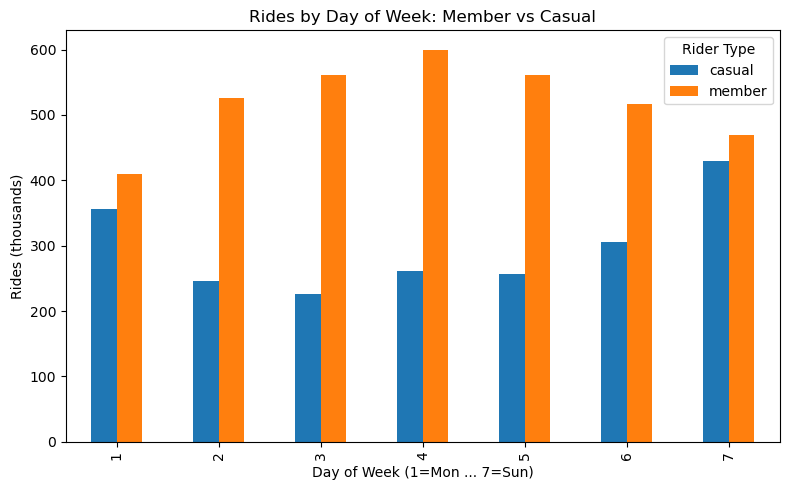

In [ ]:
# reshape: day_of_week becomes the index, member_casual becomes columns
pivot = df.pivot(index='day_of_week', columns='member_casual', values='rides_in_thousands')

pivot.plot(kind='bar', figsize=(8, 5))
plt.title('Rides by Day of Week: Member vs Casual')
plt.xlabel('Day of Week (1=Mon ... 7=Sun)')
plt.ylabel('Rides (thousands)')
plt.legend(title='Rider Type')
plt.tight_layout()
plt.show()

In [ ]:
df_month=pd.read_csv('/home/husain/Desktop/datascience_conda/Project-DA/bikes/job_owBaQOMeGGfuaacv6qsWde6Zech5.csv')
df_month.shape

(24, 3)

<Axes: title={'center': 'to be decided'}>

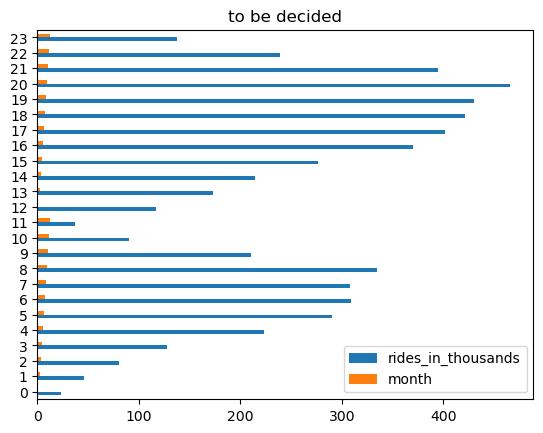

In [ ]:
df_month.plot(kind='barh',title='to be decided')

In [ ]:
df_month.columns

Index(['rides_in_thousands', 'member_casual', 'month'], dtype='object')

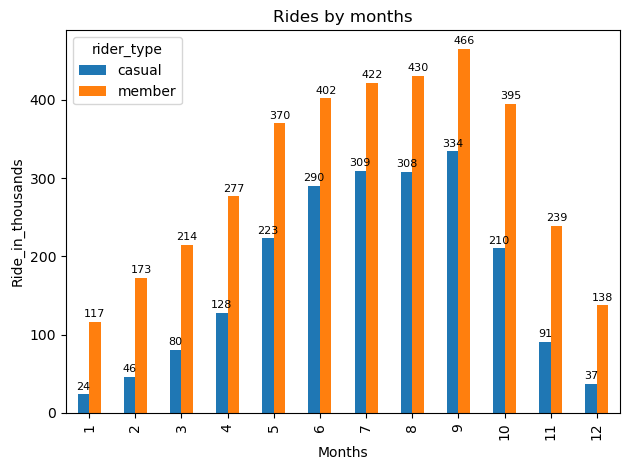

In [ ]:
pivot=df_month.pivot(index='month',columns='member_casual',values='rides_in_thousands')
ax=pivot.plot(kind='bar',title='Rides by months')
plt.xlabel('Months')
plt.ylabel('Ride_in_thousands')
plt.legend(title='rider_type')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

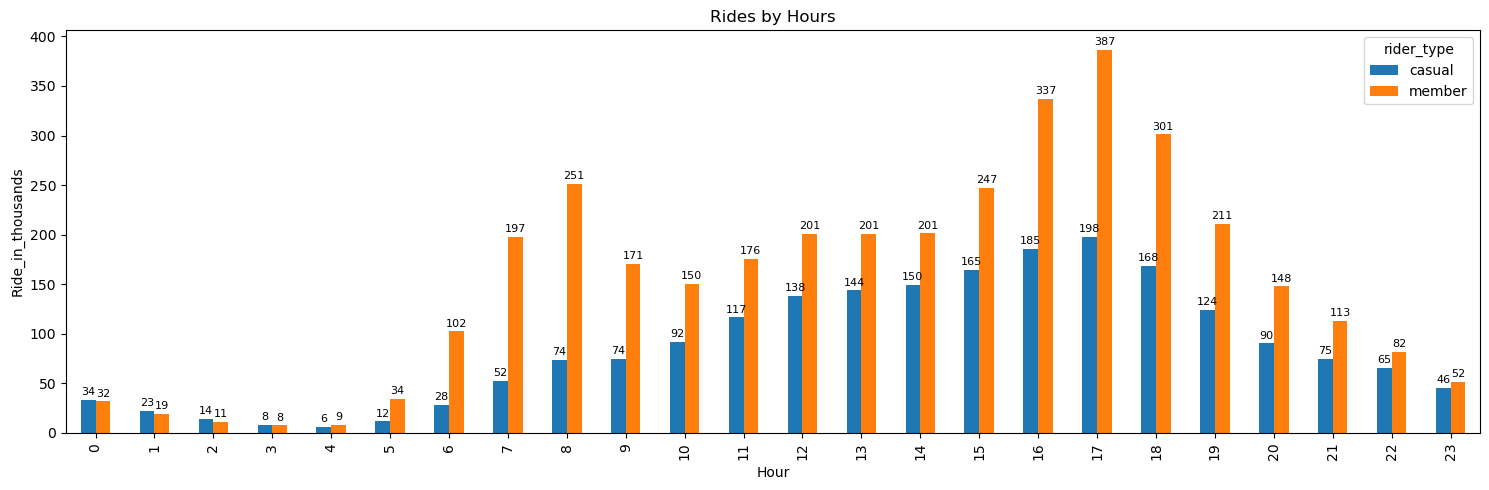

In [ ]:
path='/home/husain/Desktop/datascience_conda/Project-DA/bikes/job_NbVVXJzeXguyuVxXBFTak5XUN9ro.csv'
# index='Hour',columns='member_casual',
df_hour=pd.read_csv(path)
pivot=df_hour.pivot(index='Hour',columns='member_casual',values='rides_in_thousands')
ax=pivot.plot(kind='bar',title='Rides by Hours',figsize=(15,5))
plt.xlabel('Hour')
plt.ylabel('Ride_in_thousands')
plt.legend(title='rider_type')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

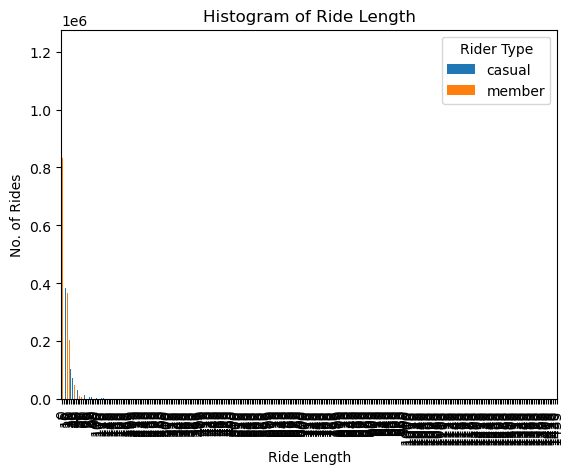

In [ ]:
#  index = length_bucket, columns= member_casual , value= rides


df_len_bucket=pd.read_csv('/home/husain/Desktop/datascience_conda/Project-DA/bikes/job_Teqwynkmot4zVRO53BUVyarWxFQ_.csv')
pivot=df_len_bucket.pivot(index='length_bucket',columns='member_casual',values='rides')
ax=pivot.plot(kind='bar')
plt.title('Histogram of Ride Length')
plt.xlabel('Ride Length')
plt.ylabel('No. of Rides')
plt.legend(title='Rider Type')
plt.show()


In [ ]:
print(df_len_bucket['length_bucket'].nunique())
print(df_len_bucket['length_bucket'].unique()[:20])

288
[ 0  5 10 15 20 25 30 35 40 45 50 55 60 65 70 75 80 85 90 95]


/tmp/ipykernel_27326/1244141953.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df_len_bucket.groupby(['length_group', 'member_casual'])['rides'].sum().unstack()


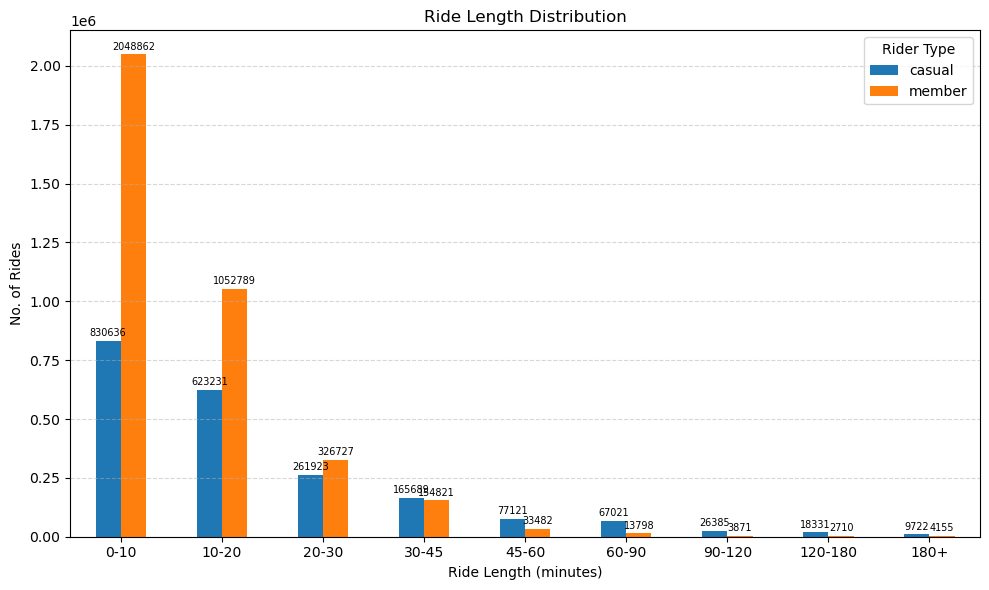

length_bucket
(0, 180]       4596829
(180, 1500]      13101
Name: rides, dtype: int64


/tmp/ipykernel_27326/1244141953.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_len_bucket.groupby(pd.cut(df_len_bucket['length_bucket'], bins=[0,180,1500]))['rides'].sum())


In [ ]:
bins = [0, 10, 20, 30, 45, 60, 90, 120, 180, float('inf')]
labels = ['0-10','10-20','20-30','30-45','45-60','60-90','90-120','120-180','180+']

df_len_bucket['length_group'] = pd.cut(df_len_bucket['length_bucket'], bins=bins, labels=labels, right=False)

pivot = df_len_bucket.groupby(['length_group', 'member_casual'])['rides'].sum().unstack()

ax = pivot.plot(kind='bar', figsize=(10,6))
plt.title('Ride Length Distribution')
plt.xlabel('Ride Length (minutes)')
plt.ylabel('No. of Rides')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Rider Type')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=7, padding=2)

plt.tight_layout()
plt.show()

print(df_len_bucket.groupby(pd.cut(df_len_bucket['length_bucket'], bins=[0,180,1500]))['rides'].sum())

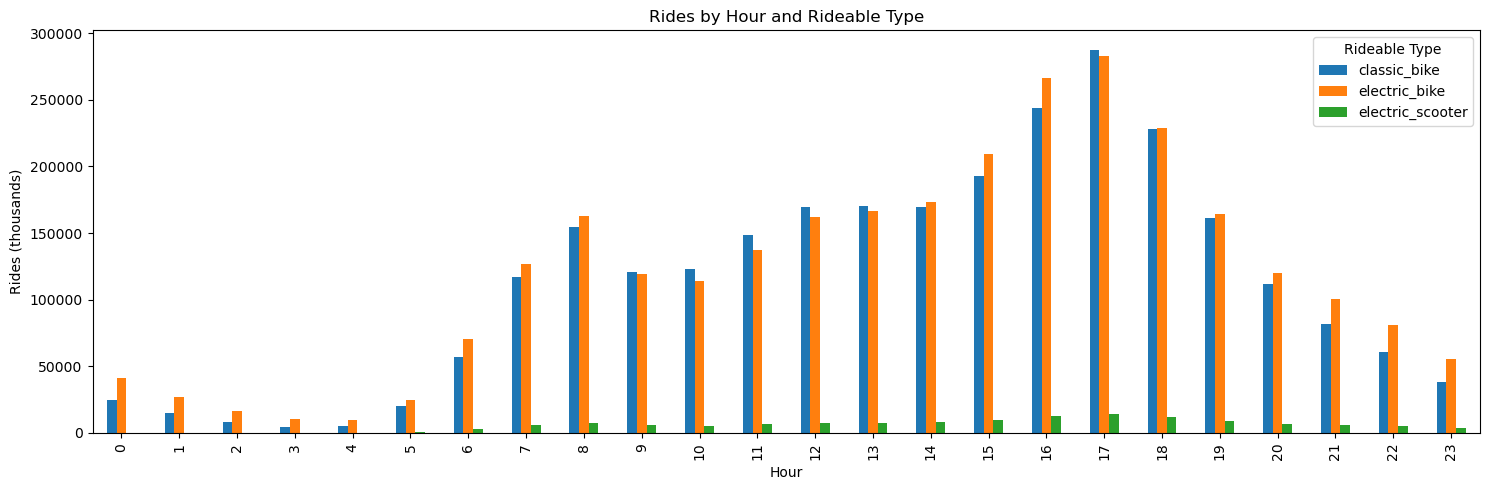

In [ ]:

# finding if rideable type is related to Hour

path='/home/husain/Desktop/datascience_conda/Project-DA/bikes/job_6PoUyzoxHVrd1x0tJWOw4j6wp-wG.csv'
# index=hour,columns=rideable_type,values=rides_in_thousands
df_rideable=pd.read_csv(path)
pivot=df_rideable.pivot(index='hour',columns='rideable_type',values='rides_in_thousands')
ax=pivot.plot(kind='bar',title='Rides by Hour and Rideable Type',figsize=(15,5))
plt.xlabel('Hour')
plt.ylabel('Rides (thousands)')
plt.legend(title='Rideable Type')
plt.tight_layout()
plt.show()

I am no genuis but i couldn't conclude anything from about rides by hour and rideable type data 

/tmp/ipykernel_27326/1064892276.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df_len_bucket.groupby(['length_group', 'rideable_type'])['rides_in_thousands'].sum().unstack()


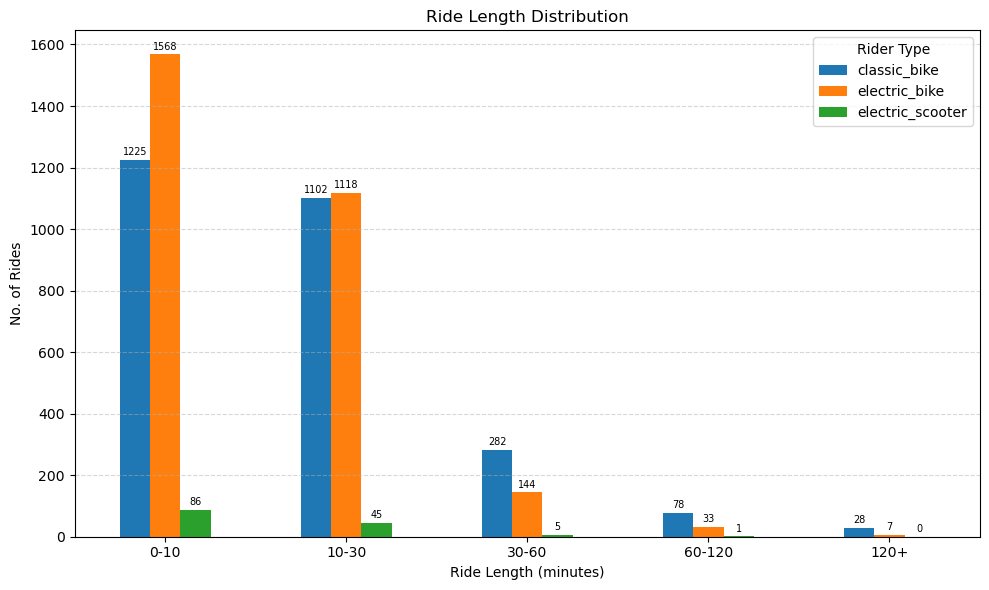

In [ ]:
# finding if rideable type is related to the ride length, we can use a pivot table to see the average ride length for each rideable type and rider type.

# I need bucketed ride length minutes, grouped by rideable_type 
path='/home/husain/Desktop/datascience_conda/Project-DA/bikes/job_RIX2wtFQBfJFjDHUERLt1GCzfjhm.csv'

bins = [0, 10, 30, 60, 120, float('inf')]
labels = ['0-10','10-30','30-60','60-120','120+']

df_len_bucket=pd.read_csv(path)
pivot=df_len_bucket.pivot(index='length_bucket',columns='rideable_type',values='rides_in_thousands')

df_len_bucket['length_group'] = pd.cut(df_len_bucket['length_bucket'], bins=bins, labels=labels, right=False)

pivot = df_len_bucket.groupby(['length_group', 'rideable_type'])['rides_in_thousands'].sum().unstack()

ax = pivot.plot(kind='bar', figsize=(10,6))
plt.title('Ride Length Distribution')
plt.xlabel('Ride Length (minutes)')
plt.ylabel('No. of Rides')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Rider Type')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=7, padding=2)

plt.tight_layout()
plt.show()


# honestly i didn't write this block of code,  just copy pasted it from the block above where we used buckets 


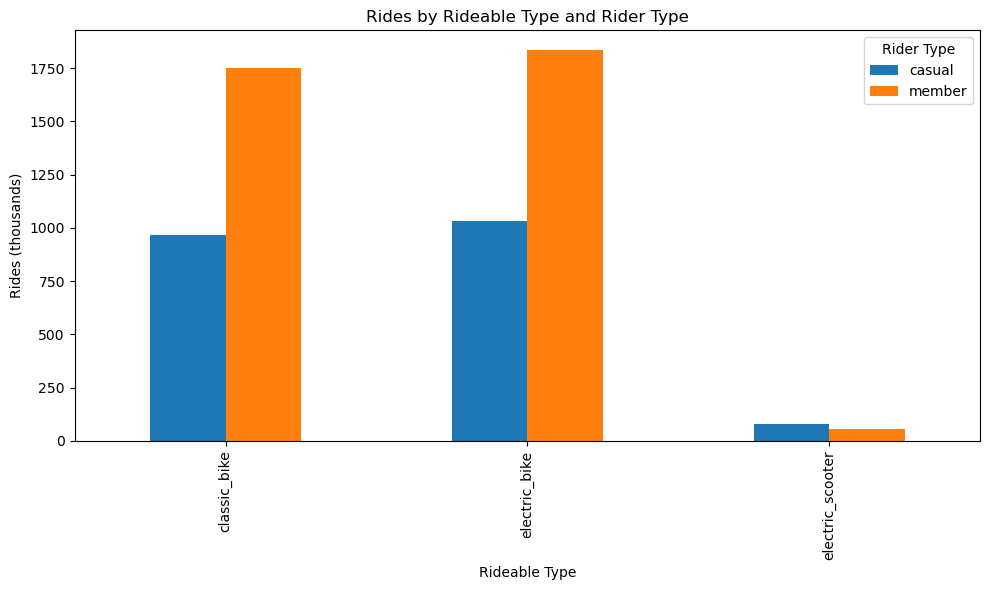

In [ ]:
# what do they ride index= rideable_type, columns= member_casual , value= rides_in_thousands
path='/home/husain/Desktop/datascience_conda/Project-DA/bikes/job_2xZLP2Anmo2tiCu15cjVFCt0Q2tW.csv'

df_rideable=pd.read_csv(path)
pivot=df_rideable.pivot(index='rideable_type',columns='member_casual',values='rides_in_thousands')
ax=pivot.plot(kind='bar',title='Rides by Rideable Type and Rider Type',figsize=(10,6))
plt.xlabel('Rideable Type')
plt.ylabel('Rides (thousands)')
plt.legend(title='Rider Type')
plt.tight_layout()
plt.show()
# this was pretty easy after doing those heavy viz before 

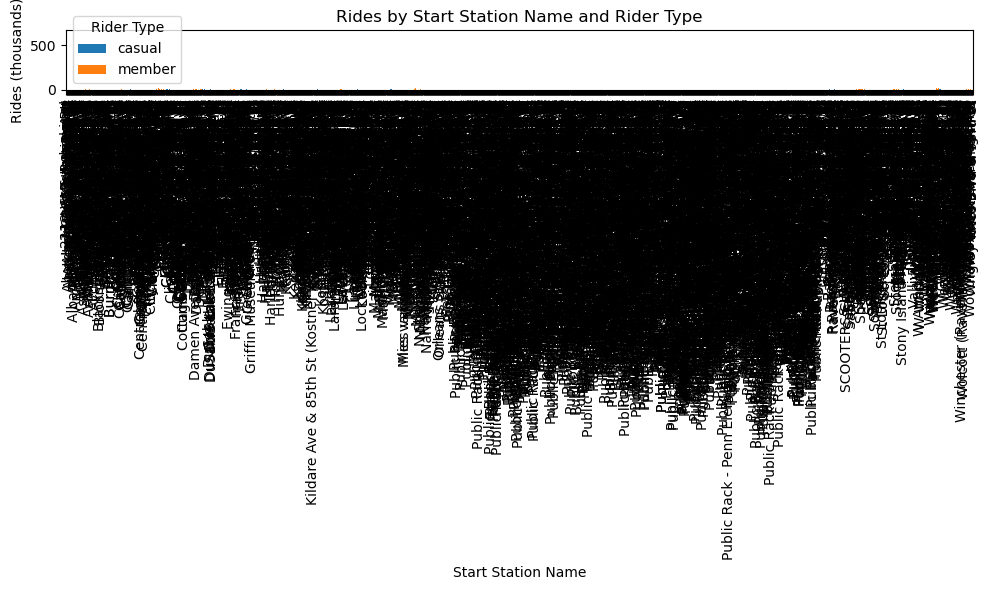

In [ ]:
path='job_ab6h9tMpvHmW-h1IJoUg-0NHm_03.csv'


# df_rideable=pd.read_csv(path)
# pivot=df_rideable.pivot(index='start_station_name',columns='member_casual',values='rides_in_thousands')
# ax=pivot.plot(kind='bar',title='Rides by Start Station Name and Rider Type',figsize=(10,6))
# plt.xlabel('Start Station Name')
# plt.ylabel('Rides (thousands)')
# plt.legend(title='Rider Type')
# plt.tight_layout()
# plt.show()

# only uncomment if you wanna see horror


what horror is this
-- ps- this created a problem as there 1390 distinct stations man, that's crazy  ( I will look about it later)

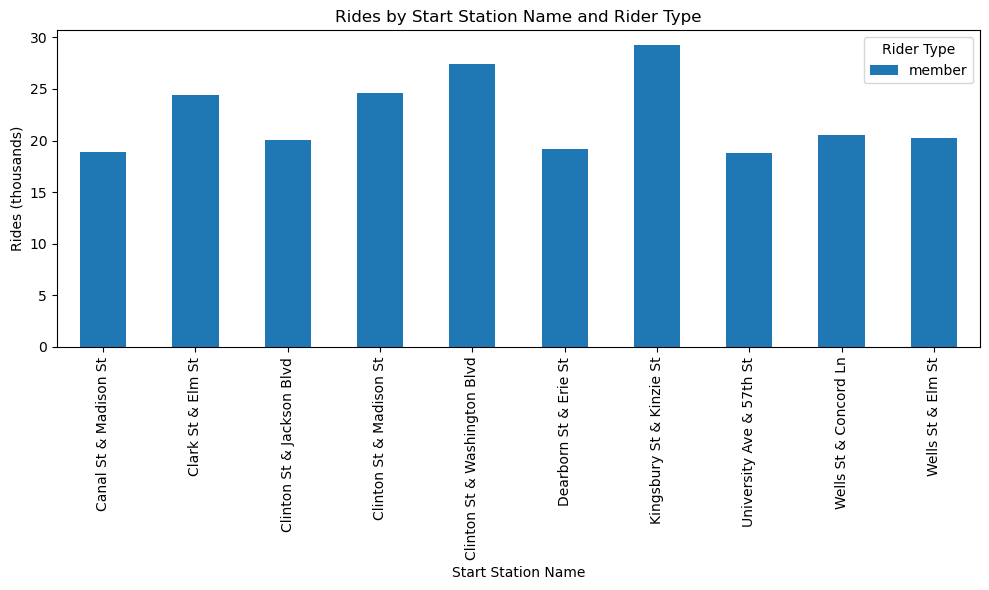

In [ ]:
path='job_KADhnoeJyRkzlvTHq1mGU30bIR_6.csv'

# top 10 stations where members go


df_member=pd.read_csv(path)
pivot=df_member.pivot(index='start_station_name',columns='member_casual',values='rides_in_thousands')
ax=pivot.plot(kind='bar',title='Rides by Start Station Name and Rider Type',figsize=(10,6))
plt.xlabel('Start Station Name')
plt.ylabel('Rides (thousands)')
plt.legend(title='Rider Type')
plt.tight_layout()
plt.show()

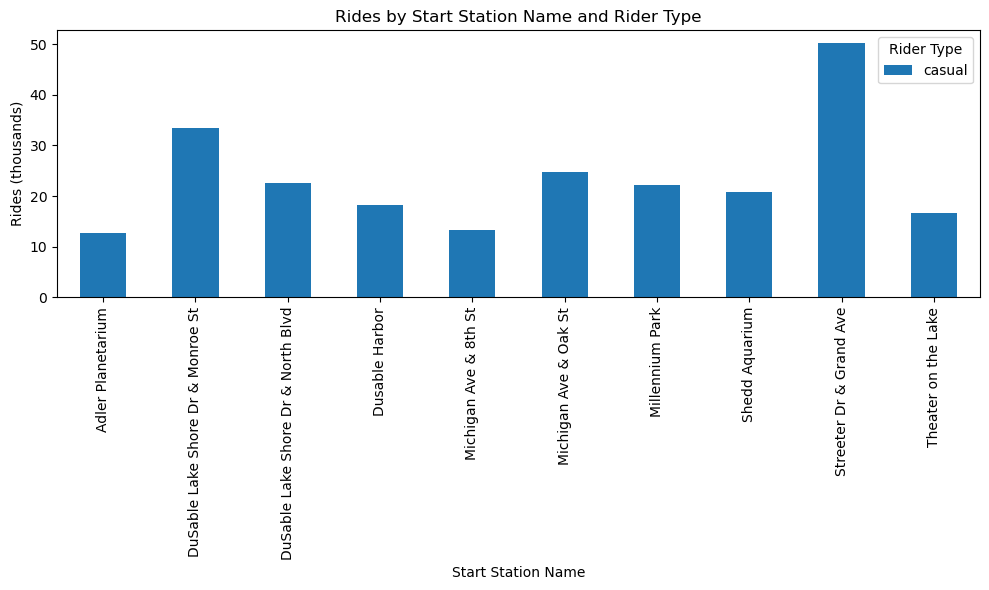

In [ ]:
path='/home/husain/Desktop/datascience_conda/Project-DA/bikes/job_wUbPTO0nAUpyOgKVmrtOKEda52R3.csv'
#top 10 stations where casuals go

df_casual=pd.read_csv(path)
pivot=df_casual.pivot(index='start_station_name',columns='member_casual',values='rides_in_thousands')
ax=pivot.plot(kind='bar',title='Rides by Start Station Name and Rider Type',figsize=(10,6))
plt.xlabel('Start Station Name')
plt.ylabel('Rides (thousands)')
plt.legend(title='Rider Type')
plt.tight_layout()
plt.show()

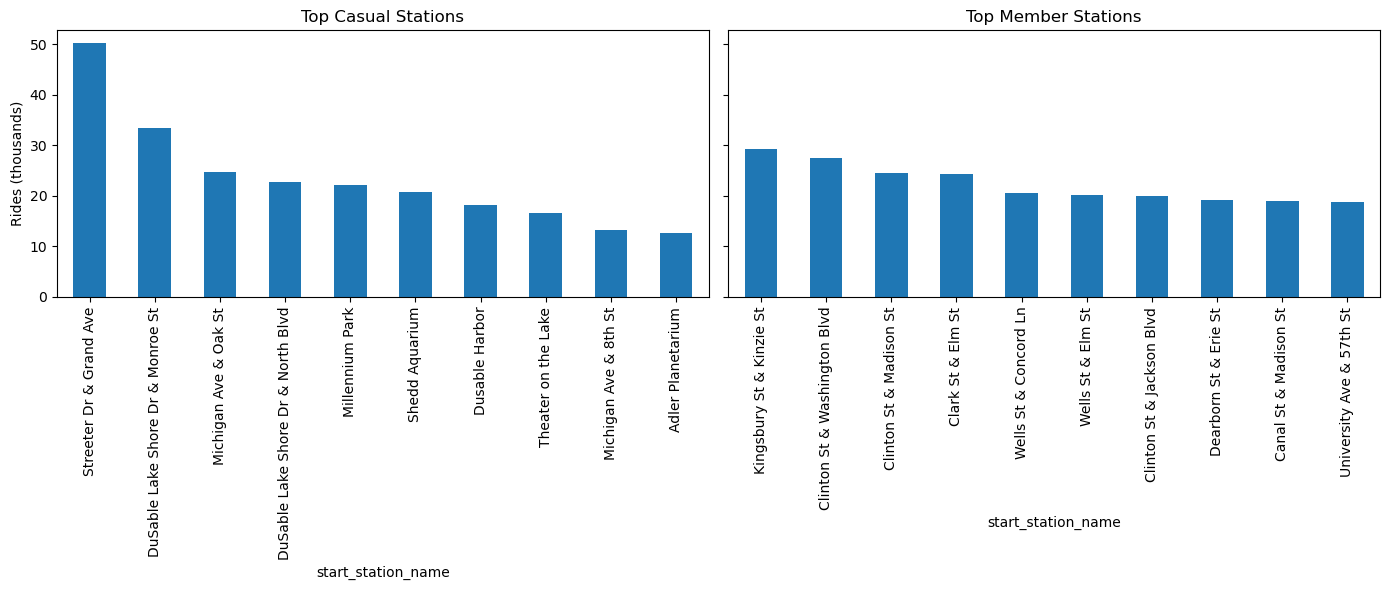

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# plot casual data on ax1
df_casual.plot(kind='bar', x='start_station_name', y='rides_in_thousands', ax=ax1, legend=False)
ax1.set_title('Top Casual Stations')
ax1.set_ylabel('Rides (thousands)')

# plot member data on ax2
df_member.plot(kind='bar', x='start_station_name', y='rides_in_thousands', ax=ax2, legend=False)
ax2.set_title('Top Member Stations')

plt.tight_layout()
plt.show()

#copy pasted code here in this cell